## Building images 
Any two dimensional image can be made only from sine function. This can be done using sinusoidal gratings. A sinusoidal Grating is a 2D representation in which amplitude varies sinusoidally along a certain direction. 


Moving from 1D sine wave to 2D sinusoidal gratings

<Figure size 640x480 with 0 Axes>

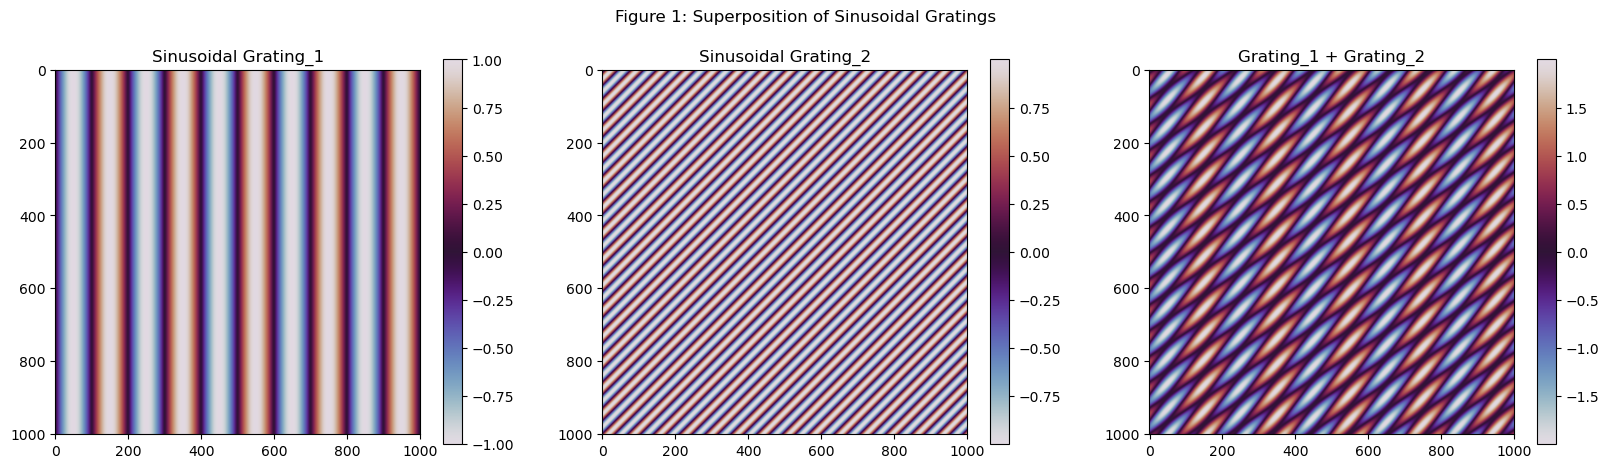

In [18]:
import numpy as np
import matplotlib.pyplot as plt
x= np.arange(-500,501,1)
X,Y= np.meshgrid(x,x)
w1=200 #wavelength
a1= 0 #angle
w2=50
a2= np.pi/4
grating1 = np.sin(2*np.pi*(X*np.cos(a1)+Y*np.sin(a1))/w1)
grating2 = np.sin(2*np.pi*(X*np.cos(a2)+Y*np.sin(a2))/w2)
grating = grating1 + grating2

plt.set_cmap("twilight")
plt.figure(figsize=(20,5))

plt.suptitle("Figure 1: Superposition of Sinusoidal Gratings")

plt.subplot(131)
plt.imshow(grating1)
plt.title("Sinusoidal Grating_1")
plt.colorbar()
plt.subplot(132)
plt.imshow(grating2)
plt.title("Sinusoidal Grating_2")
plt.colorbar()
plt.subplot(133)
plt.imshow(grating)
plt.title("Grating_1 + Grating_2")
plt.colorbar()
plt.show()

#### A sinusoidal grating is characterised by four parameters:
- wavelength or frequency
- amplitude
- orientation
- phase


<!-- Functions to calculate Fourier and inverse fourier Transforms -->

In [15]:
# functions to perform fourier transforms

def do_fourier(input):
    ft=np.fft.ifftshift(input)
    ft=np.fft.fft2(ft)
    return np.fft.fftshift(ft)
def do_inverse_fourier(input):
    ift= np.fft.ifftshift(input)
    ift= np.fft.ifft2(ift)
    ift= np.fft.fftshift(ift)
    return ift.real


 2D Fourier transform of grating(s) 

Text(0.5, 1.0, 'Phase spectrum of grating')

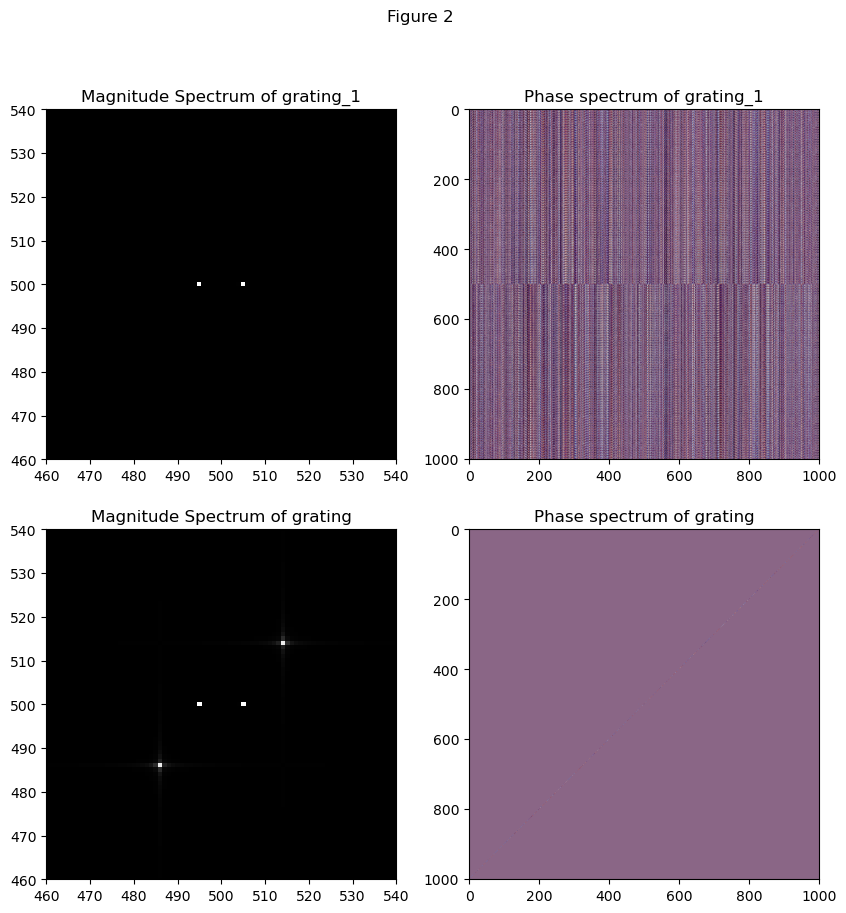

In [19]:
fft_1= do_fourier(grating1)
fft= do_fourier(grating)
plt.figure(figsize=(10,10))
plt.suptitle("Figure 2")
plt.subplot(221)
plt.imshow(abs(fft_1), cmap="gray")
plt.xlim([460,540])
plt.ylim([460,540])
plt.title("Magnitude Spectrum of grating_1")
plt.subplot(222)
plt.imshow(np.angle(fft_1))
plt.title("Phase spectrum of grating_1")
plt.subplot(223)
plt.imshow(abs(fft), cmap="gray")
plt.xlim([460,540])
plt.ylim([460,540])
plt.title("Magnitude Spectrum of grating")
plt.subplot(224)
plt.imshow(np.angle(fft))
plt.title("Phase spectrum of grating")

Some examples of Fourier Transforms 

Delta function centred at origin

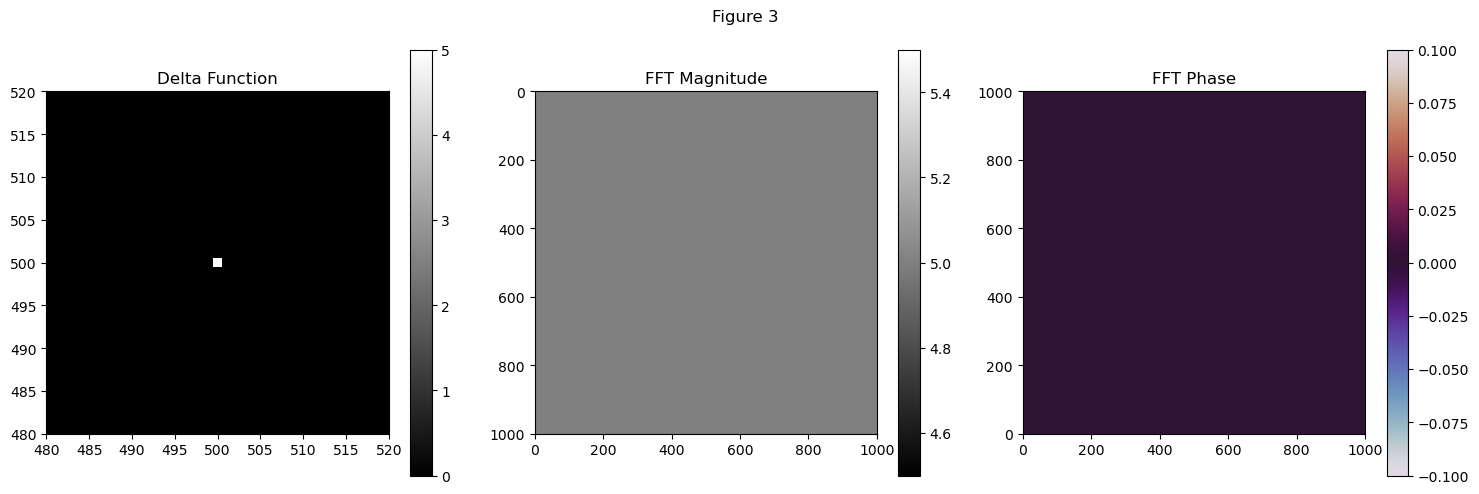

In [5]:
size = 1001
delta = np.zeros((size, size))
#delta[450:550,450:550] = 5
delta[500,500] = 5

F_shifted=do_fourier(delta)
magnitude = np.abs(F_shifted)
phase = np.angle(F_shifted)
p=phase/np.pi
plt.figure(figsize=(15,5))
plt.suptitle("Figure 3")

plt.subplot(1, 3, 1)
plt.title("Delta Function")
plt.xlim(480,520)
plt.ylim(480,520)
plt.imshow(delta, cmap='gray', origin='lower')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("FFT Magnitude")
plt.imshow(magnitude, cmap='gray')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("FFT Phase")
plt.imshow(p, cmap='twilight', origin='lower')
plt.colorbar()
plt.tight_layout()
plt.show()


Off centered Delta function

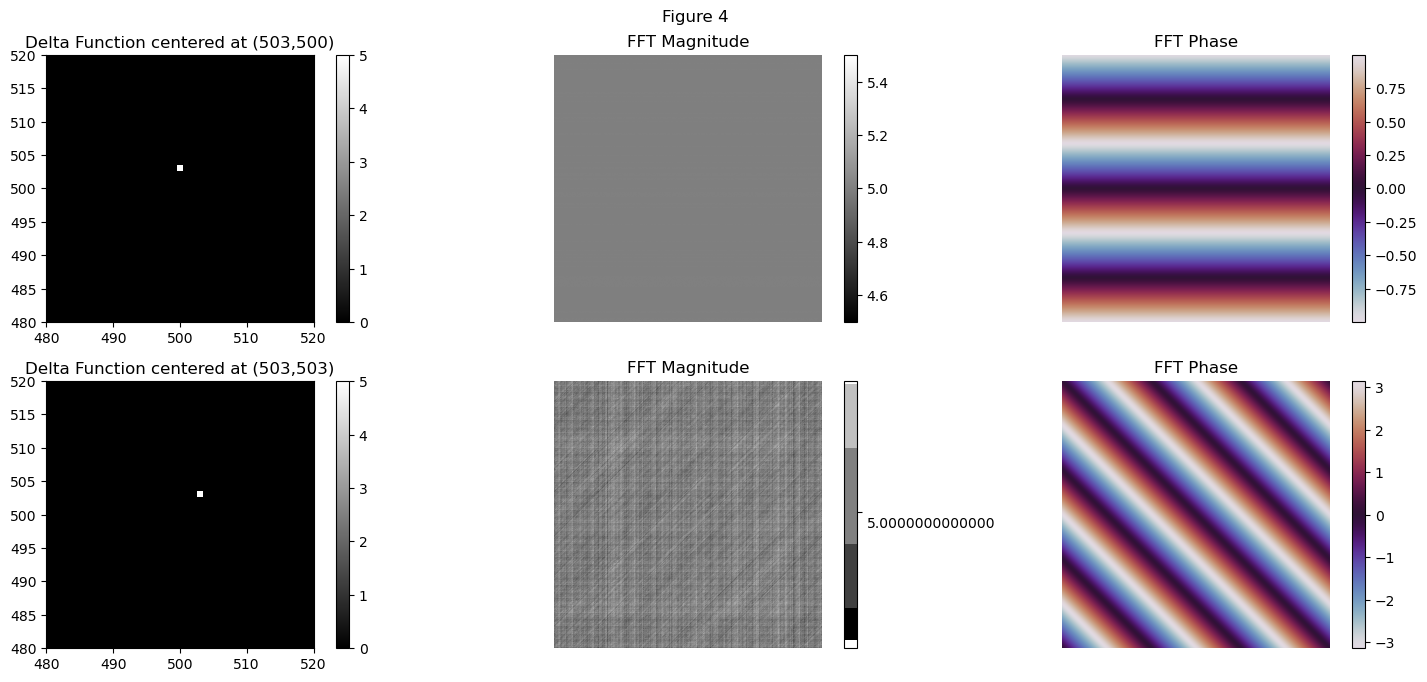

In [ ]:
size = 1001
delta = np.zeros((size, size))
delta_both_shifted= np.zeros((size,size))
delta_both_shifted[503,503]=5
delta[503,500] = 5

F_shifted=do_fourier(delta)
both_shifted= do_fourier(delta_both_shifted)
magnitude = np.abs(F_shifted)
phase = np.angle(F_shifted)
p=phase/np.pi
mag_both=np.abs(both_shifted)
phase_both= np.angle(both_shifted)

plt.figure(figsize=(15,10))
plt.suptitle("Figure 4")

plt.subplot(3, 3, 1)
plt.title("Delta Function centered at (503,500)")
plt.imshow(delta, cmap='gray', origin='lower')
plt.xlim(480,520)
plt.ylim(480,520)
plt.colorbar()

plt.subplot(3, 3, 2)
plt.title("FFT Magnitude")
plt.imshow(magnitude, cmap='gray')
plt.colorbar()
plt.axis('off')

plt.subplot(3, 3, 3)
plt.title("FFT Phase")
plt.imshow(p, cmap='twilight', origin='lower')
plt.colorbar()
plt.axis('off')

plt.subplot(3, 3, 4)
plt.title("Delta Function centered at (503,503)")
plt.imshow(delta_both_shifted, cmap='gray', origin='lower')
plt.xlim(480,520)
plt.ylim(480,520)
plt.colorbar()

plt.subplot(3, 3, 5)
plt.title("FFT Magnitude")
plt.imshow(mag_both, cmap='gray')
plt.colorbar()
plt.axis('off')

plt.subplot(3, 3, 6)
plt.title("FFT Phase")
plt.imshow(phase_both, cmap='twilight', origin='lower')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

Narrow Gaussian

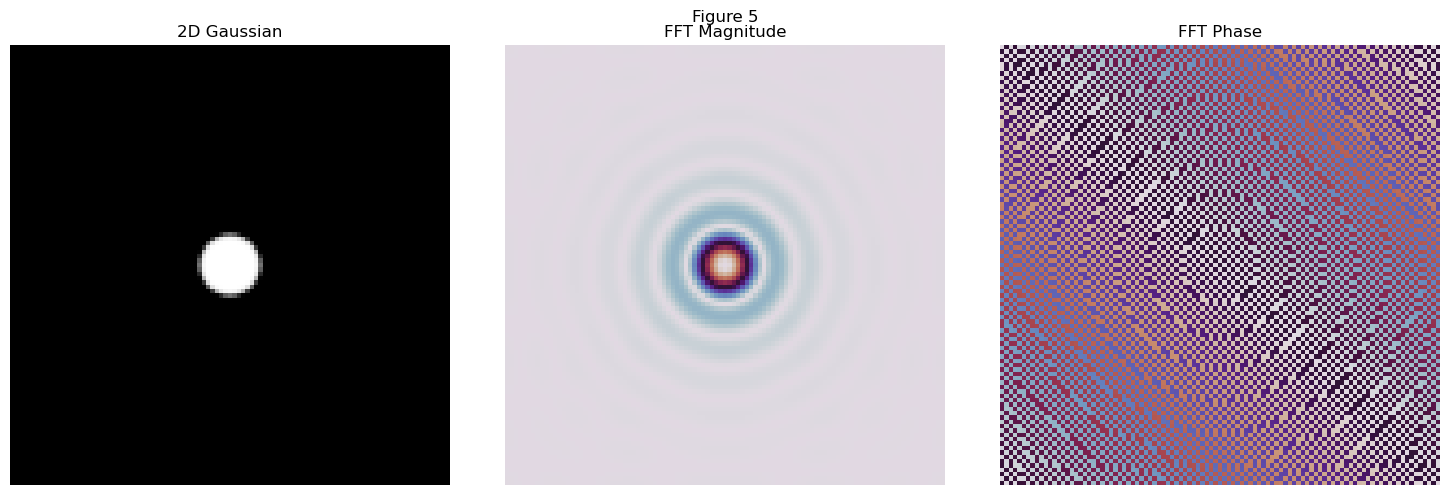

In [21]:
size = 101
sigma = 5
x = np.linspace(-50, 50, size)
y = np.linspace(-50, 50, size)
X, Y = np.meshgrid(x, y)
gaussian = np.exp(-((X**2 + Y**2) / (2 * sigma**2))**10)

fft_result = np.fft.fft2(gaussian)
fft_shifted = np.fft.fftshift(fft_result) 
magnitude = np.abs(fft_shifted)
phase = np.angle(fft_shifted)

plt.figure(figsize=(15, 5))
plt.suptitle("Figure 5")

plt.subplot(1, 3, 1)
plt.imshow(gaussian, cmap='gray', origin='lower')
plt.title("2D Gaussian")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(magnitude, cmap='twilight', origin='lower')
plt.title("FFT Magnitude")
plt.axis('off')

# Phase Spectrum
plt.subplot(1, 3, 3)
plt.imshow(phase, cmap='twilight', origin='lower')
plt.title("FFT Phase")
plt.axis('off')

plt.tight_layout()
plt.show()


Wider gaussian

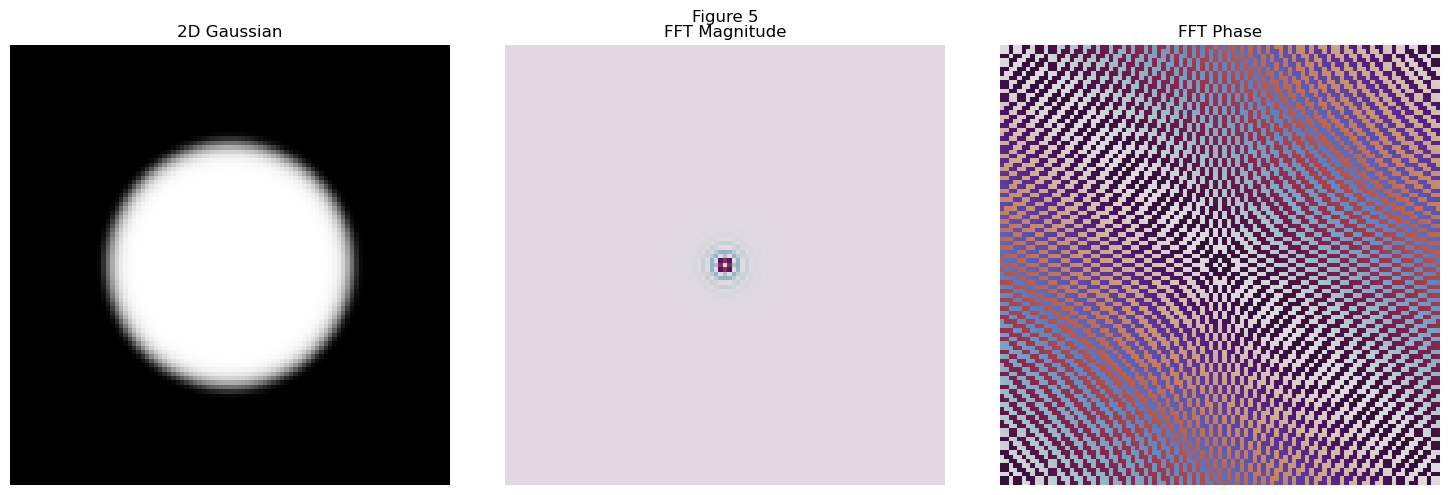

In [ ]:
size = 101
sigma = 20
x = np.linspace(-50, 50, size)
y = np.linspace(-50, 50, size)
X, Y = np.meshgrid(x, y)
gaussian = np.exp(-((X**2 + Y**2) / (2 * sigma**2))**10)

fft_result = np.fft.fft2(gaussian)
fft_shifted = np.fft.fftshift(fft_result) 
magnitude = np.abs(fft_shifted)
phase = np.angle(fft_shifted)

plt.figure(figsize=(15, 5))
plt.suptitle("Figure 5")

plt.subplot(1, 3, 1)
plt.imshow(gaussian, cmap='gray', origin='lower')
plt.title("2D Gaussian")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(magnitude, cmap='twilight', origin='lower')
plt.title("FFT Magnitude")
plt.axis('off')

# Phase Spectrum
plt.subplot(1, 3, 3)
plt.imshow(phase, cmap='twilight', origin='lower')
plt.title("FFT Phase")
plt.axis('off')

plt.tight_layout()
plt.show()


- Narrow features become wide in fourier space and vice-versa.
- Narrow peaks corresponds to high spatial frequency while wide peaks or features correspond to low spatial frequency.


Removing  low frequency features from fourier transform of an image

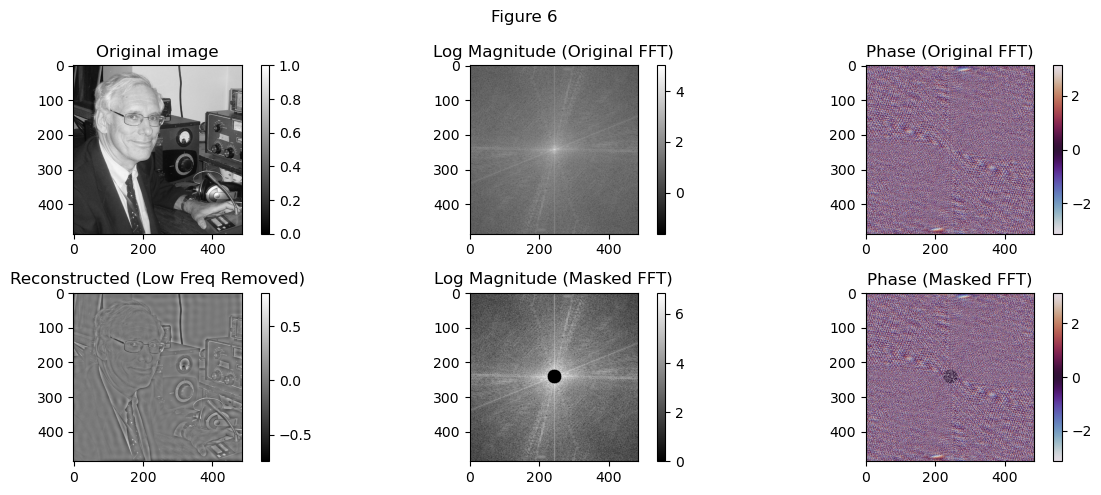

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

img = imread(r'/home/amandeep-kaur/aspire-black-hole-project/images/JamesMichaelMoran.png') #---> need to change
if img.ndim == 3:
    img = img.mean(axis=2)

# Ensure square and odd-sized array
array_size = min(img.shape)
if array_size % 2 == 0:
    array_size -= 1
img = img[:array_size, :array_size]

image_fft = do_fourier(img)

# Create circular mask to remove low frequencies
height, width = image_fft.shape
centre = array_size // 2
radius = 20

Y, X = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
distance = np.sqrt((X - centre)**2 + (Y - centre)**2)
mask = distance > radius  # keep high frequencies only

# Apply the mask
fft_new = image_fft * mask
masked_image =do_inverse_fourier(fft_new)

# Plotting
plt.figure(figsize=(12, 5))
plt.suptitle("Figure 6")

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original image")
plt.colorbar()

plt.subplot(2, 3, 2)
plt.imshow(np.log10(np.abs(image_fft)), cmap='gray')
plt.title("Log Magnitude (Original FFT)")
plt.colorbar()

plt.subplot(2,3 , 3)
plt.imshow(np.angle(image_fft), cmap='twilight')
plt.title("Phase (Original FFT)")
plt.colorbar()

# Reconstructed image
plt.subplot(2, 3, 4)
plt.imshow(masked_image, cmap='gray')
plt.title("Reconstructed (Low Freq Removed)")
plt.colorbar()

plt.subplot(2, 3, 5)
plt.imshow(np.log1p(np.abs(fft_new)), cmap='gray')
plt.title("Log Magnitude (Masked FFT)")
plt.colorbar()

plt.subplot(2, 3, 6)
plt.imshow(np.angle(fft_new), cmap='twilight')
plt.title("Phase (Masked FFT)")
plt.colorbar()

plt.tight_layout()
plt.show()

Removing  high frequency features from fourier transform of an image

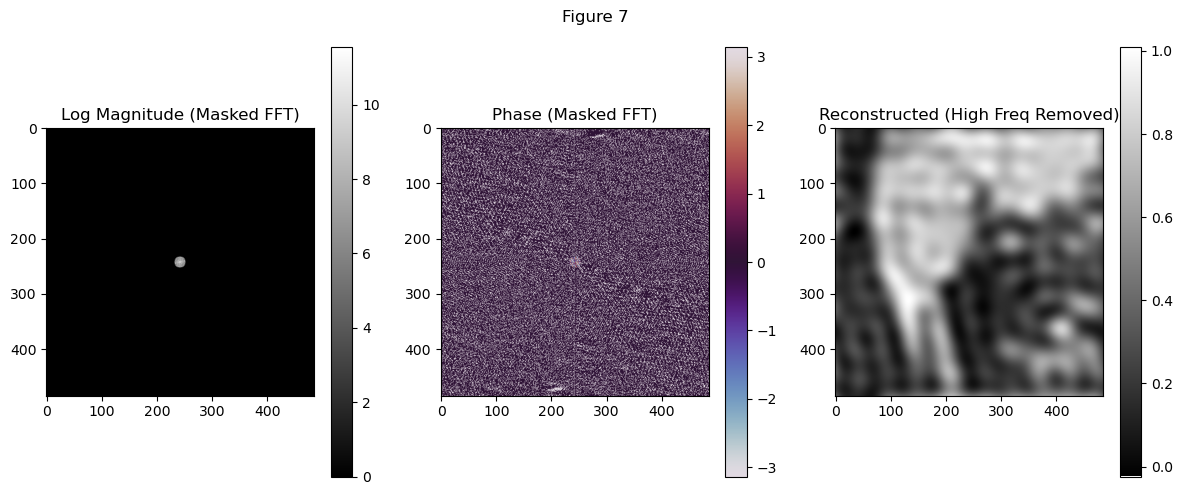

In [30]:

# Create circular mask to remove high frequencies
height, width = image_fft.shape
centre = array_size // 2
radius = 10

Y, X = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
distance = np.sqrt((X - centre)**2 + (Y - centre)**2)
mask = distance <= radius  # keep low frequencies only

fft_new = image_fft * mask
masked_image = do_inverse_fourier(fft_new)

# Plotting
plt.figure(figsize=(12, 5))
plt.suptitle("Figure 7")

plt.subplot(1, 3, 1)
plt.imshow(np.log1p(np.abs(fft_new)), cmap='gray')
plt.title("Log Magnitude (Masked FFT)")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(np.angle(fft_new), cmap='twilight')
plt.title("Phase (Masked FFT)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(masked_image, cmap='gray')
plt.title("Reconstructed (High Freq Removed)")
plt.colorbar()

plt.tight_layout()
plt.show()


- Low frequency in fourier space is responsible for the background and overall shape of the picture.
- High frequencies are responsible for details, edges and fine patterns in the picture.